In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
traffic = 1000

In [3]:
p_A = 0.20
p_B = 0.23

In [4]:
np.random.seed(30)

In [5]:
convert_A = np.random.binomial(1, p_A, traffic)
convert_B = np.random.binomial(1, p_B, traffic)

In [6]:
df = pd.DataFrame(
    {
        'Groups': ['A'] * traffic + ['B'] * traffic,
        'Conversion': np.concatenate([convert_A, convert_B])
    }
)

In [7]:
df

,Groups,Conversion
0,A,0
1,A,0
2,A,0
3,A,0
4,A,1
...,...,...
1995,B,1
1996,B,0
1997,B,0
1998,B,0


In [8]:
#Count how many people converted
#Count how many people total
#Compute the average

summary = df.groupby('Groups')['Conversion'].agg(['sum', 'count', 'mean'])

In [9]:
summary.rename(columns={"mean": "conversion_rate"}, inplace=True)

In [10]:
summary

,sum,count,conversion_rate
Groups,,,
A,211,1000,0.211
B,236,1000,0.236


<Axes: xlabel='Groups'>

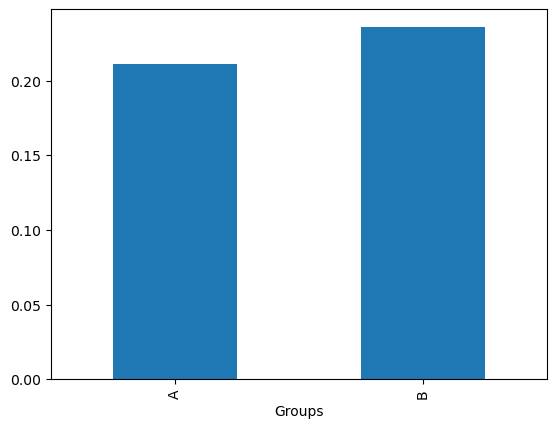

In [11]:
summary['conversion_rate'].plot(kind='bar')

In [12]:
# Frequentist test
from scipy.stats import ttest_ind

In [13]:
# “If A and B were actually the same, how likely is it to see a difference this big?”
t_stat, p_value = ttest_ind(
    df[df.Groups == "A"]["Conversion"],
    df[df.Groups == "B"]["Conversion"]
)

# If p < 0.05 → statistically significant
# If p ≥ 0.05 → not statistically significant

p_value

np.float64(0.1798072449399297)

In [14]:
# Counting data

a_success = summary.loc['A', 'sum']
a_fail = summary.loc['A', 'count'] - a_success

print(a_success)
print(a_fail)

b_success = summary.loc['B', 'sum']
b_fail = summary.loc['B', 'count'] - b_success

211
789


In [21]:
# Using beta
from scipy.stats import beta

a_beta = beta(1 + a_success, 1 + a_fail)
b_beta = beta(1 + b_success, 1 + b_fail)


# Define x values for the plot (range of values for the x-axis)
x = np.linspace(0, 0.35, 1000)

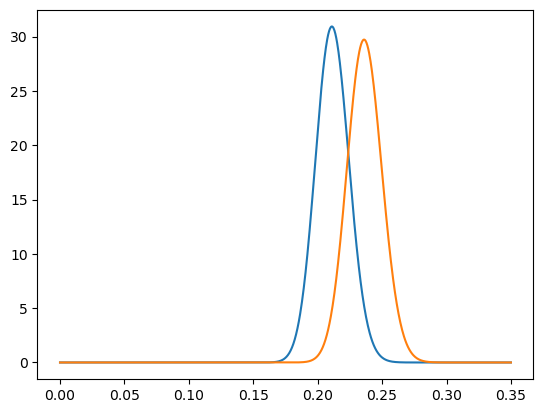

In [22]:
# Visualize Data MatPlotLib
plt.plot(x, a_beta.pdf(x))
plt.plot(x, b_beta.pdf(x))

In [23]:
# Sampling

sample_A = a_beta.rvs(10000)
sample_B = b_beta.rvs(10000)

In [25]:
# Result

np.mean(sample_B > sample_A)

np.float64(0.9121)